Epoch 1/1000, Loss: 101.9230
Epoch 2/1000, Loss: 99.7900
Epoch 3/1000, Loss: 97.9265
Epoch 4/1000, Loss: 95.8715
Epoch 5/1000, Loss: 93.3248
Epoch 6/1000, Loss: 93.2356
Epoch 7/1000, Loss: 91.1469
Epoch 8/1000, Loss: 88.6907
Epoch 9/1000, Loss: 86.9550
Epoch 10/1000, Loss: 85.2189
Epoch 11/1000, Loss: 83.4516
Epoch 12/1000, Loss: 81.8551
Epoch 13/1000, Loss: 80.3819
Epoch 14/1000, Loss: 79.3725
Epoch 15/1000, Loss: 77.2193
Epoch 16/1000, Loss: 75.9511
Epoch 17/1000, Loss: 74.2157
Epoch 18/1000, Loss: 72.5037
Epoch 19/1000, Loss: 71.2115
Epoch 20/1000, Loss: 70.1174
Epoch 21/1000, Loss: 68.7978
Epoch 22/1000, Loss: 66.9084
Epoch 23/1000, Loss: 65.5304
Epoch 24/1000, Loss: 64.6382
Epoch 25/1000, Loss: 63.0645
Epoch 26/1000, Loss: 62.0832
Epoch 27/1000, Loss: 60.3307
Epoch 28/1000, Loss: 59.7924
Epoch 29/1000, Loss: 58.0782
Epoch 30/1000, Loss: 57.3675
Epoch 31/1000, Loss: 55.6705
Epoch 32/1000, Loss: 55.0921
Epoch 33/1000, Loss: 54.0466
Epoch 34/1000, Loss: 52.5631
Epoch 35/1000, Loss: 5

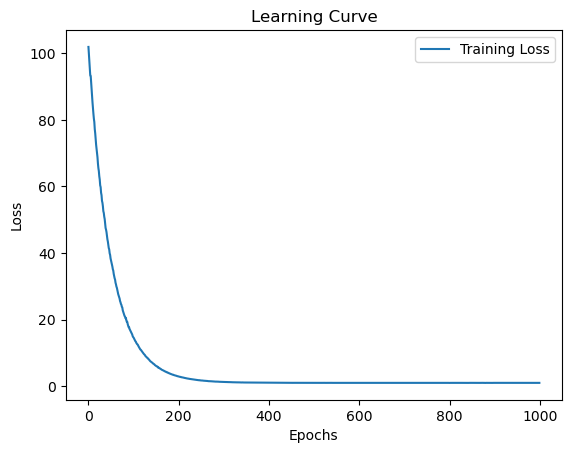

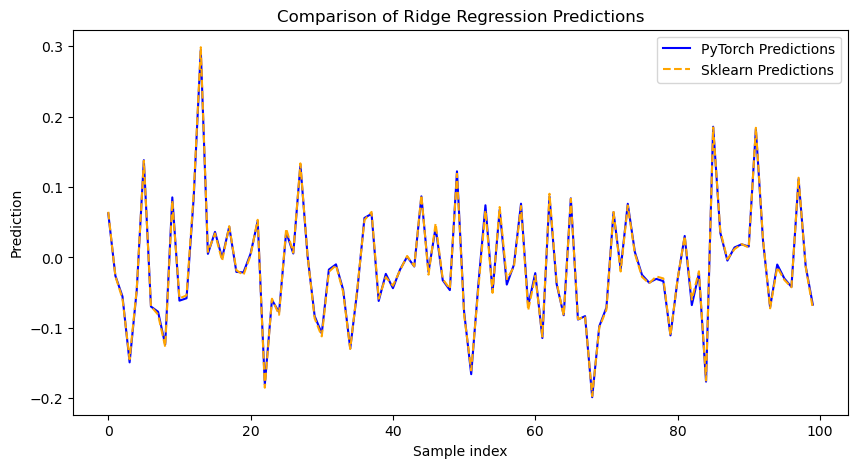

In [53]:

import torch
import torch.optim as optim
from sklearn.linear_model import Ridge as SklearnRidge
import matplotlib.pyplot as plt
import numpy as np

class Ridge:
    def __init__(self, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y, epochs=1000, lr=0.01):
        n_samples, n_features = X.shape
        self.w = torch.randn(n_features, 1, requires_grad=True, device=self.device)
        if self.fit_intercept:
            self.b = torch.randn(1, requires_grad=True, device=self.device)

        optimizer = optim.SGD([self.w] + ([self.b] if self.fit_intercept else []), lr=lr)

        for epoch in range(epochs):
            # Shuffle the data at the beginning of each epoch
            indices = torch.randperm(n_samples, device=self.device)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0.0  # Track total loss for this epoch
            num_batches = (n_samples + self.batch_size - 1) // self.batch_size

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # Forward pass
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / num_batches
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


    def model(self, x):
        return x @ self.w + (self.b if self.fit_intercept else 0)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.w ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

if __name__ == "__main__":
    # Check for available device
    device =  ('cuda' if torch.cuda.is_available() else 'cpu')
    # device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')

    # Generate synthetic data
    X_torch = torch.randn(13000, 100).to(device)
    y_torch = torch.randn(13000, 1).to(device)

    # PyTorch Ridge Model
    torch_ridge = Ridge(alpha=1e-3, fit_intercept=True, batch_size=3000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=1000, lr=0.001)
    # torch_ridge = Ridge(alpha=1e-3, fit_intercept=True, batch_size=13000, device=device)
    # torch_ridge.fit(X_torch, y_torch, epochs=400, lr=0.01)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Sklearn Ridge Model for comparison
    X_sklearn = X_torch.cpu().numpy()
    y_sklearn = y_torch.cpu().numpy().ravel()
    sklearn_ridge = SklearnRidge(alpha=1e-3, fit_intercept=True)
    sklearn_ridge.fit(X_sklearn, y_sklearn)
    sklearn_predictions = sklearn_ridge.predict(X_sklearn)

    # PyTorch predictions
    torch_predictions = torch_ridge.predict(X_torch)

    # Plotting results
    plt.figure(figsize=(10, 5))
    plt.plot(torch_predictions[:100], label="PyTorch Predictions", color="blue")
    plt.plot(sklearn_predictions[:100], label="Sklearn Predictions", color="orange", linestyle="dashed")
    plt.xlabel("Sample index")
    plt.ylabel("Prediction")
    plt.title("Comparison of Ridge Regression Predictions")
    plt.legend()
    plt.show()


## try multioutput

Epoch 1/60, Loss: 90.2752
Epoch 2/60, Loss: 76.0056
Epoch 3/60, Loss: 64.0325
Epoch 4/60, Loss: 53.9825
Epoch 5/60, Loss: 45.5461
Epoch 6/60, Loss: 38.4617
Epoch 7/60, Loss: 32.5112
Epoch 8/60, Loss: 27.5124
Epoch 9/60, Loss: 23.3118
Epoch 10/60, Loss: 19.7808
Epoch 11/60, Loss: 16.8122
Epoch 12/60, Loss: 14.3158
Epoch 13/60, Loss: 12.2160
Epoch 14/60, Loss: 10.4493
Epoch 15/60, Loss: 8.9626
Epoch 16/60, Loss: 7.7112
Epoch 17/60, Loss: 6.6576
Epoch 18/60, Loss: 5.7702
Epoch 19/60, Loss: 5.0227
Epoch 20/60, Loss: 4.3929
Epoch 21/60, Loss: 3.8622
Epoch 22/60, Loss: 3.4147
Epoch 23/60, Loss: 3.0375
Epoch 24/60, Loss: 2.7194
Epoch 25/60, Loss: 2.4510
Epoch 26/60, Loss: 2.2246
Epoch 27/60, Loss: 2.0334
Epoch 28/60, Loss: 1.8721
Epoch 29/60, Loss: 1.7359
Epoch 30/60, Loss: 1.6209
Epoch 31/60, Loss: 1.5237
Epoch 32/60, Loss: 1.4416
Epoch 33/60, Loss: 1.3722
Epoch 34/60, Loss: 1.3135
Epoch 35/60, Loss: 1.2640
Epoch 36/60, Loss: 1.2220
Epoch 37/60, Loss: 1.1866
Epoch 38/60, Loss: 1.1565
Epoch 3

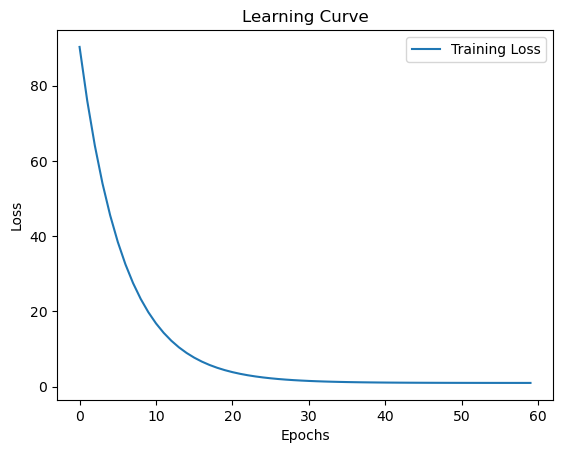

Predictions shape: (13000, 3)


In [69]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

class Ridge:
    def __init__(self, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y, epochs=1000, lr=0.01):
        n_samples, n_features = X.shape
        n_outputs = y.shape[1]  # Adjust for multiple outputs
        self.w = torch.randn(n_features, n_outputs, requires_grad=True, device=self.device)
        if self.fit_intercept:
            self.b = torch.randn(1, n_outputs, requires_grad=True, device=self.device)

        optimizer = optim.SGD([self.w] + ([self.b] if self.fit_intercept else []), lr=lr)

        for epoch in range(epochs):
            # Shuffle data indices at the beginning of each epoch
            indices = torch.randperm(n_samples)
            
            epoch_loss = 0.0
            num_batches = (n_samples + self.batch_size - 1) // self.batch_size

            for i in range(0, n_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                
                # Move mini-batches to the GPU in each iteration
                X_batch = X[batch_indices].to(self.device)
                y_batch = y[batch_indices].to(self.device)

                # Forward pass
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / num_batches
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


    def model(self, x):
        return x @ self.w + (self.b if self.fit_intercept else 0)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.w ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

if __name__ == "__main__":
    # Check for available device
    device = ('cuda' if torch.cuda.is_available() else 'cpu')

    # Generate synthetic data with multiple outputs
    X_torch = torch.randn(13000, 100).to('cpu')
    y_torch = torch.randn(13000, 3).to('cpu')  # Multi-output target

    # PyTorch Ridge Model
    torch_ridge = Ridge(alpha=1e-3, fit_intercept=True, batch_size=100, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=60, lr=0.001)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions should now have shape (13000, 3)
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)  # Expected (13000, 3)
    sklearn_ridge.fit(X_sklearn, y_sklearn)
    sklearn_predictions = sklearn_ridge.predict(X_sklearn)

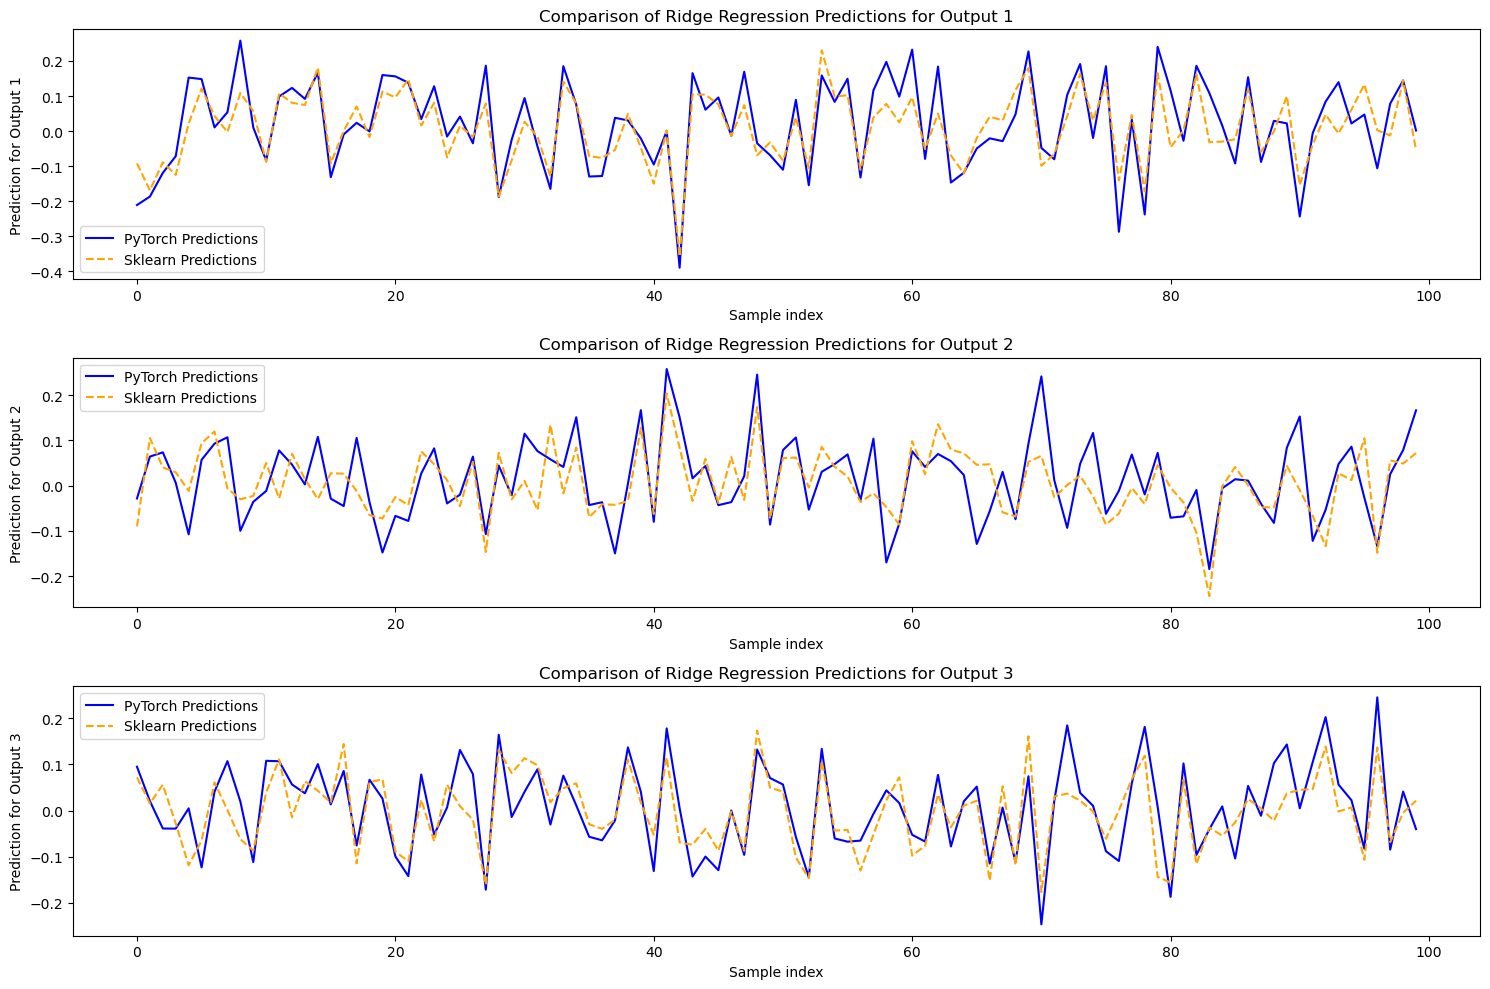

In [70]:
# Sklearn Ridge Model
X_sklearn = X_torch.cpu().numpy()
y_sklearn = y_torch.cpu().numpy()
sklearn_ridge = SklearnRidge(alpha=1e-3, fit_intercept=True)
sklearn_ridge.fit(X_sklearn, y_sklearn)
sklearn_predictions = sklearn_ridge.predict(X_sklearn)
# Predictions for first 100 samples to visualize
torch_predictions = torch_ridge.predict(X_torch)[:100]
sklearn_predictions = sklearn_predictions[:100]

# Plotting results for all three outputs
plt.figure(figsize=(15, 10))

for i in range(3):  # Loop over each output dimension
    plt.subplot(3, 1, i + 1)
    plt.plot(torch_predictions[:, i], label="PyTorch Predictions", color="blue")
    plt.plot(sklearn_predictions[:, i], label="Sklearn Predictions", color="orange", linestyle="dashed")
    plt.xlabel("Sample index")
    plt.ylabel(f"Prediction for Output {i+1}")
    plt.title(f"Comparison of Ridge Regression Predictions for Output {i+1}")
    plt.legend()

plt.tight_layout()
plt.show()

In [58]:
for i in range(3):
    print(i)

0
1
2


## nn.Linear layer version

Epoch 1/60, Loss: 1.2831
Epoch 2/60, Loss: 1.2377
Epoch 3/60, Loss: 1.1995
Epoch 4/60, Loss: 1.1675
Epoch 5/60, Loss: 1.1406
Epoch 6/60, Loss: 1.1180
Epoch 7/60, Loss: 1.0990
Epoch 8/60, Loss: 1.0831
Epoch 9/60, Loss: 1.0697
Epoch 10/60, Loss: 1.0584
Epoch 11/60, Loss: 1.0490
Epoch 12/60, Loss: 1.0410
Epoch 13/60, Loss: 1.0343
Epoch 14/60, Loss: 1.0287
Epoch 15/60, Loss: 1.0239
Epoch 16/60, Loss: 1.0199
Epoch 17/60, Loss: 1.0166
Epoch 18/60, Loss: 1.0137
Epoch 19/60, Loss: 1.0113
Epoch 20/60, Loss: 1.0093
Epoch 21/60, Loss: 1.0076
Epoch 22/60, Loss: 1.0062
Epoch 23/60, Loss: 1.0050
Epoch 24/60, Loss: 1.0040
Epoch 25/60, Loss: 1.0031
Epoch 26/60, Loss: 1.0024
Epoch 27/60, Loss: 1.0018
Epoch 28/60, Loss: 1.0013
Epoch 29/60, Loss: 1.0008
Epoch 30/60, Loss: 1.0005
Epoch 31/60, Loss: 1.0002
Epoch 32/60, Loss: 0.9999
Epoch 33/60, Loss: 0.9997
Epoch 34/60, Loss: 0.9995
Epoch 35/60, Loss: 0.9993
Epoch 36/60, Loss: 0.9992
Epoch 37/60, Loss: 0.9991
Epoch 38/60, Loss: 0.9990
Epoch 39/60, Loss: 0.

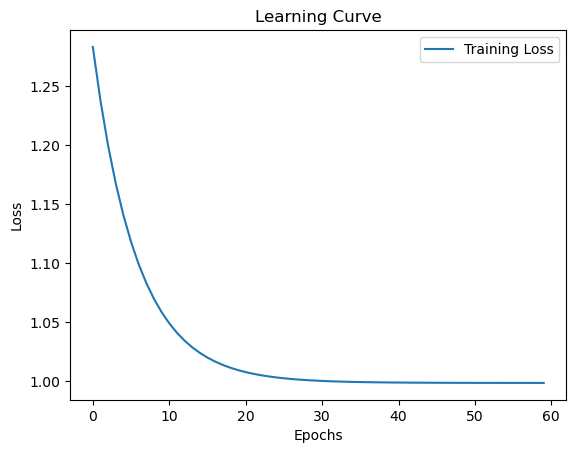

Predictions shape: (13000, 3)


In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

class Ridge:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        
        # Define the nn.Linear layer with the fit_intercept parameter controlling bias
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)

    def fit(self, X, y, epochs=1000, lr=0.01):
        n_samples = X.shape[0]
        
        optimizer = optim.SGD(self.linear.parameters(), lr=lr)

        for epoch in range(epochs):
            indices = torch.randperm(n_samples)
            epoch_loss = 0.0
            num_batches = (n_samples + self.batch_size - 1) // self.batch_size

            for i in range(0, n_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                X_batch = X[batch_indices].to(self.device)
                y_batch = y[batch_indices].to(self.device)

                # Forward pass using the nn.Linear layer
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / num_batches
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    def model(self, x):
        return self.linear(x)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

if __name__ == "__main__":
    device = ('cuda' if torch.cuda.is_available() else 'cpu')

    # Generate synthetic data
    X_torch = torch.randn(13000, 100).to('cpu')
    y_torch = torch.randn(13000, 3).to('cpu')

    # Instantiate and train the model
    torch_ridge = Ridge(input_dim=100, output_dim=3, alpha=1e-3, fit_intercept=True, batch_size=100, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=60, lr=0.001)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)


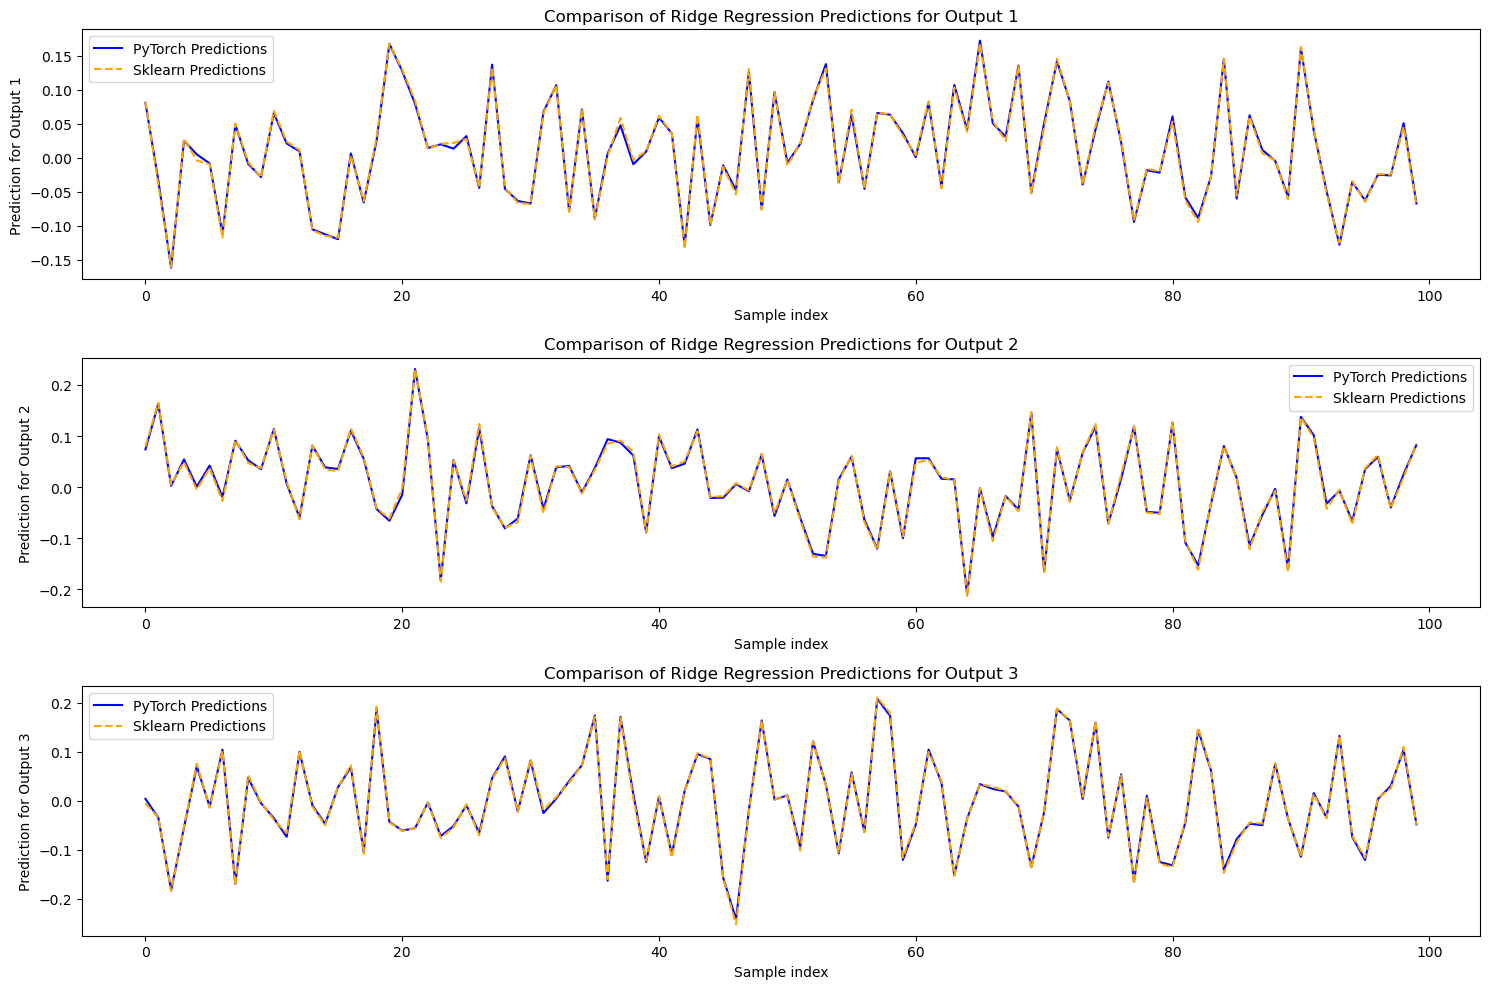

In [11]:

import torch
import torch.optim as optim
from sklearn.linear_model import Ridge as SklearnRidge
import matplotlib.pyplot as plt
import numpy as np
# Sklearn Ridge Model
X_sklearn = X_torch.cpu().numpy()
y_sklearn = y_torch.cpu().numpy()
sklearn_ridge = SklearnRidge(alpha=1e-3, fit_intercept=True)
sklearn_ridge.fit(X_sklearn, y_sklearn)
sklearn_predictions = sklearn_ridge.predict(X_sklearn)
# Predictions for first 100 samples to visualize
torch_predictions = torch_ridge.predict(X_torch)[:100]
sklearn_predictions = sklearn_predictions[:100]

# Plotting results for all three outputs
plt.figure(figsize=(15, 10))

for i in range(3):  # Loop over each output dimension
    plt.subplot(3, 1, i + 1)
    plt.plot(torch_predictions[:, i], label="PyTorch Predictions", color="blue")
    plt.plot(sklearn_predictions[:, i], label="Sklearn Predictions", color="orange", linestyle="dashed")
    plt.xlabel("Sample index")
    plt.ylabel(f"Prediction for Output {i+1}")
    plt.title(f"Comparison of Ridge Regression Predictions for Output {i+1}")
    plt.legend()

plt.tight_layout()
plt.show()

## Try now with EEG simulations

Epoch 1/60, Loss: 1.2750
Epoch 2/60, Loss: 1.2293
Epoch 3/60, Loss: 1.1909
Epoch 4/60, Loss: 1.1588
Epoch 5/60, Loss: 1.1319
Epoch 6/60, Loss: 1.1094
Epoch 7/60, Loss: 1.0905
Epoch 8/60, Loss: 1.0747
Epoch 9/60, Loss: 1.0614
Epoch 10/60, Loss: 1.0502
Epoch 11/60, Loss: 1.0409
Epoch 12/60, Loss: 1.0330
Epoch 13/60, Loss: 1.0265
Epoch 14/60, Loss: 1.0209
Epoch 15/60, Loss: 1.0163
Epoch 16/60, Loss: 1.0124
Epoch 17/60, Loss: 1.0091
Epoch 18/60, Loss: 1.0064
Epoch 19/60, Loss: 1.0041
Epoch 20/60, Loss: 1.0021
Epoch 21/60, Loss: 1.0005
Epoch 22/60, Loss: 0.9991
Epoch 23/60, Loss: 0.9980
Epoch 24/60, Loss: 0.9970
Epoch 25/60, Loss: 0.9962
Epoch 26/60, Loss: 0.9955
Epoch 27/60, Loss: 0.9949
Epoch 28/60, Loss: 0.9944
Epoch 29/60, Loss: 0.9940
Epoch 30/60, Loss: 0.9937
Epoch 31/60, Loss: 0.9934
Epoch 32/60, Loss: 0.9932
Epoch 33/60, Loss: 0.9930
Epoch 34/60, Loss: 0.9928
Epoch 35/60, Loss: 0.9926
Epoch 36/60, Loss: 0.9925
Epoch 37/60, Loss: 0.9924
Epoch 38/60, Loss: 0.9923
Epoch 39/60, Loss: 0.

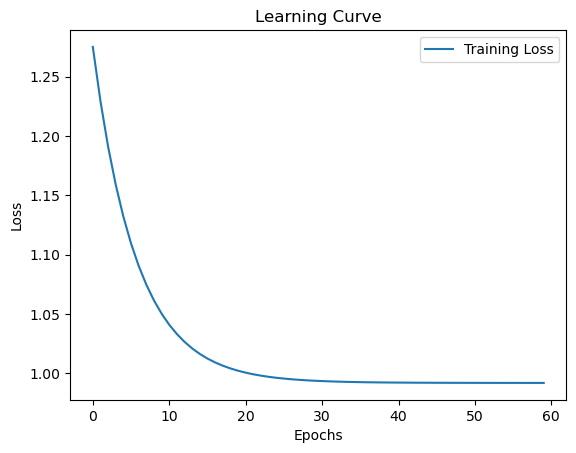

Predictions shape: (13000, 3)


In [12]:

device = ('cuda' if torch.cuda.is_available() else 'cpu')

# Generate synthetic data
X_torch = torch.randn(13000, 100).to('cpu')
y_torch = torch.randn(13000, 3).to('cpu')

# Instantiate and train the model
torch_ridge = Ridge(input_dim=100, output_dim=3, alpha=1e-3, fit_intercept=True, batch_size=100, device=device)
torch_ridge.fit(X_torch, y_torch, epochs=60, lr=0.001)

# Plot learning curve
torch_ridge.plot_learning_curve()

# Predictions
torch_predictions = torch_ridge.predict(X_torch)

print("Predictions shape:", torch_predictions.shape)

In [74]:
y

tensor(0.8848, grad_fn=<DotBackward0>)

In [5]:
for i in range(1,10,4):
    print(i)

1
5
9


In [13]:
 torch_ridge.linear.weight.detach().cpu().numpy()

array([[ 0.02078412,  0.00040729, -0.00781126,  0.00651732, -0.00096974,
        -0.0082637 ,  0.01573304, -0.02039019,  0.00629703,  0.00304816,
         0.00710382, -0.0034818 , -0.0017569 , -0.00150318,  0.01191014,
        -0.00359854,  0.00064343,  0.0025149 ,  0.00633704,  0.01557656,
         0.01296911, -0.00050582, -0.00237355,  0.00232681, -0.00921866,
         0.01418706, -0.02191336,  0.00049023, -0.00403633, -0.01774876,
        -0.00160635, -0.01058279, -0.00790839,  0.00799002, -0.0048127 ,
         0.00874846, -0.00462566,  0.01080048, -0.01056278,  0.00903075,
        -0.00796703,  0.00014995, -0.01702816, -0.00533851, -0.00375126,
         0.01070798,  0.00431972,  0.00345479,  0.00998523, -0.0087405 ,
         0.00147632, -0.00896464, -0.00041986, -0.00022464, -0.00023606,
        -0.00385283, -0.01733137, -0.000266  , -0.00048192, -0.00173811,
         0.00166857,  0.00680457, -0.01212993,  0.00676394, -0.00910594,
        -0.02188763,  0.00340316, -0.00227484, -0.0

In [14]:
torch_ridge

# prototype for impproving create_design_matrix

In [15]:
import numpy as np
from scipy.sparse import csr_matrix, lil_matrix

def create_design_matrix(raw, tmin, tmax, sr, events, intercept_evt, feature_cols, interaction=None):
    """Create the design matrix for the regression model, optimized for speed and memory usage."""
    
    # Handle feature columns and count predictors
    if not feature_cols:
        feature_cols = []
    elif isinstance(feature_cols, str):
        feature_cols = [feature_cols]
    n_predictors = len(feature_cols)

    # Calculate delays and zero index
    delays = _delays(tmin, tmax, sr)
    n_samples_window = len(delays)
    zero_idx = closest_indices(delays, 0)

    # Filter and prepare event data
    evt_to_model = events[events['type'] == intercept_evt].copy()
    evt_to_model['type'] = 1  # Assign intercept
    features = ['type'] + feature_cols

    # Process interaction terms if specified
    if interaction:
        beta_int0, beta_int1 = interaction[0].split(':')
        interaction_col = 'interaction'
        feature_cols.append(interaction_col)
        evt_to_model[interaction_col] = evt_to_model[beta_int0] * evt_to_model[beta_int1]
        n_predictors += 1

    expanded_params = (1 + n_predictors) * n_samples_window
    signal_length_in_samples = raw.n_times
    X_sparse = lil_matrix((signal_length_in_samples, expanded_params))

    # Event latencies
    evt_lat = evt_to_model['latency'].values.astype(int)

    # Fill design matrix efficiently
    for beta in range(n_predictors + 1):
        feature_vals = evt_to_model[features[beta]].values
        for delay_idx, delay in enumerate(delays):
            col = beta * n_samples_window + delay_idx
            rows = evt_lat + delay - zero_idx
            valid_rows = rows[(rows >= 0) & (rows < signal_length_in_samples)]
            X_sparse[valid_rows, col] = feature_vals[(rows >= 0) & (rows < signal_length_in_samples)]

    return csr_matrix(X_sparse)  # Convert to CSR format for efficient processing


In [ ]:

import pandas as pd
import mne
from pydeconv.utils import *
from pydeconv import *
from sklearn.model_selection import KFold, GridSearchCV
import torch
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
# Check for available device
device = ('cuda' if torch.cuda.is_available() else 'cpu')

# Class to test GPU support
#==========================
# class Ridge:
#     def __init__(self, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
#         self.alpha = alpha
#         self.fit_intercept = fit_intercept
#         self.batch_size = batch_size
#         self.device = device
#         self.w = None
#         self.b = None
#         self.loss_history = []

#     def fit(self, X, y, epochs=1000, lr=0.01):
#         n_samples, n_features = X.shape
#         n_outputs = y.shape[1]  # Adjust for multiple outputs
#         self.w = torch.randn(n_features, n_outputs, requires_grad=True, device=self.device)
#         if self.fit_intercept:
#             self.b = torch.randn(1, n_outputs, requires_grad=True, device=self.device)

#         optimizer = optim.SGD([self.w] + ([self.b] if self.fit_intercept else []), lr=lr)

#         for epoch in range(epochs):
#             # Shuffle data indices at the beginning of each epoch
#             indices = torch.randperm(n_samples)
            
#             epoch_loss = 0.0
#             num_batches = (n_samples + self.batch_size - 1) // self.batch_size

#             for i in range(0, n_samples, self.batch_size):
#                 batch_indices = indices[i:i + self.batch_size]
                
#                 # Move mini-batches to the GPU in each iteration
#                 # X_batch = X[batch_indices].to(self.device)
#                 X_batch = torch.tensor(X[batch_indices].todense(), device=self.device, dtype=torch.float32)
#                 y_batch = torch.tensor(y[batch_indices], device=self.device, dtype=torch.float32)

#                 # Forward pass
#                 predictions = self.model(X_batch)
#                 loss = self.loss(predictions, y_batch)
#                 epoch_loss += loss.item()

#                 # Backward pass and optimization
#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()

#             avg_loss = epoch_loss / num_batches
#             self.loss_history.append(avg_loss)
#             print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

#     def model(self, x):
#         return x @ self.w + (self.b if self.fit_intercept else 0)

#     def loss(self, predictions, y):
#         mse_loss = torch.mean((predictions - y) ** 2)
#         ridge_penalty = self.alpha * torch.sum(self.w ** 2)
#         return mse_loss + ridge_penalty

#     def predict(self, X):
#         return self.model(X).detach().cpu().numpy()

#     def plot_learning_curve(self):
#         plt.plot(self.loss_history, label="Training Loss")
#         plt.xlabel("Epochs")
#         plt.ylabel("Loss")
#         plt.title("Learning Curve")
#         plt.legend()
#         plt.show()
class Ridge:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        
        # Define the nn.Linear layer with the fit_intercept parameter controlling bias
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)

    def fit(self, X, y, epochs=1000, lr=0.01):
        n_samples = X.shape[0]
        
        optimizer = optim.SGD(self.linear.parameters(), lr=lr )

        for epoch in range(epochs):
            indices = torch.randperm(n_samples)
            epoch_loss = 0.0
            num_batches = (n_samples + self.batch_size - 1) // self.batch_size

            for i in range(0, n_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                                
                X_batch = torch.tensor(X[batch_indices].todense(), device=self.device, dtype=torch.float32)
                y_batch = torch.tensor(y[batch_indices], device=self.device, dtype=torch.float32)



                # Forward pass using the nn.Linear layer
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / num_batches
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4e}")
            

    def model(self, x):
        return self.linear(x)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

# Load parameter, data and features
#==================================
data_path = "./example_data/"
settings = analyze_data()
features = pd.read_csv(data_path + "629959_full_metadata.csv") 
raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)

# Initialize the model
#=====================
rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)
X_design = rERP_model.create_matrix()
y_data   = rERP_model.get_nonzero_data()



Analyzing data with model: targMin
Time range: -0.2 to 0.6
Solver: ridge
Reading /Users/dac/Documents/repos/PyDeconv/example_data/629959_analysis.fdt
Reading 0 ... 1389499  =      0.000 ...  2778.998 secs...


/var/folders/gf/gp61rxzn3pz1rqw464l71d7w0000gn/T/ipykernel_40047/1969441060.py:149: RuntimeWarning: Unknown types found, setting as type EEG:
eye: ['L-AREA', 'L-GAZE-X', 'L-GAZE-Y', 'TIME']
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)
/var/folders/gf/gp61rxzn3pz1rqw464l71d7w0000gn/T/ipykernel_40047/1969441060.py:149: RuntimeWarning: Not setting positions of 8 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)



Model Name: targMin
First Intercept Event Type: fixation
Second Intercept Event Type: saccade
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 64

Model Description:
Intercept: True
Additive Features: ['ontarget']
Interactions: None

creating default splines: 5 cubic B-splines matrix


In [1]:

# GPU FIT
#========
rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)


# PyTorch Ridge Model
# torch_ridge = Ridge(alpha=1e-3, fit_intercept=True, batch_size=1000, device=device)
# torch_ridge.fit(X_design, y_data, epochs=30, lr=0.01)
torch_ridge = Ridge(input_dim=X_design.shape[1], output_dim= y_data.shape[1], alpha= 24 , fit_intercept=False, batch_size=400000, device=device)
torch_ridge.fit(X_design, y_data, epochs=10, lr=0.01)

# Plot learning curve
torch_ridge.plot_learning_curve()
coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
rERP_model.coef_ =  coeffs
# # Predictions should now have shape (13000, 3)
# torch_predictions = torch_ridge.predict(X_torch)
fig = rERP_model.plot_coefs()
plt.show()

NameError: name 'PyDeconv' is not defined

In [ ]:



# Model Selection 
#================
solver = rERP_model.estimator
num_folds = 5
alphas = np.linspace(5, 300, 13)
param_grid = {'alpha': alphas.tolist()}
# Create StratifiedKFold object
kf = KFold(n_splits=num_folds)
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=solver, param_grid=param_grid, scoring='neg_mean_squared_error', cv=kf,verbose=5)
# grid_search.fit(X_design, y_data)
# rERP_model.estimator.set_params(alpha = 40)
rERP_model.fit(X_design, y_data)

# # Extract results
# #================
# cv_results = grid_search.cv_results_
# best_model = grid_search.best_estimator_
# rERP_model.coef_ = best_model.coef_

fig = rERP_model.plot_coefs()
plt.show()

# rERP_model.coef_.shape
# rERP_model.plot_coefs()


### Using DataLoader

In [1]:

import pandas as pd
import mne
from pydeconv.utils import *
from pydeconv import *
from sklearn.model_selection import KFold, GridSearchCV
import torch
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Check for available device
device = ('cuda' if torch.cuda.is_available() else 'cpu')

class Ridge:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        
        # Define the nn.Linear layer with the fit_intercept parameter controlling bias
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)

    def fit(self, X, y, epochs=1000, lr=0.01, momentum=0):
        n_samples = X.shape[0]
        
        optimizer = optim.SGD(self.linear.parameters(), lr=lr, momentum=momentum )


        # Convert data to CPU tensors only (avoiding full GPU memory usage initially)
        X_tensor = torch.tensor(X.todense(), dtype=torch.float32)  # Keep on CPU
        y_tensor = torch.tensor(y, dtype=torch.float32)  # Keep on CPU
        dataset = TensorDataset(X_tensor, y_tensor)
        data_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        # Training loop
        for epoch in range(epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in data_loader:
                # Move mini-batch to GPU
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                
                # Forward pass
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            avg_loss = epoch_loss / len(data_loader)
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


            

    def model(self, x):
        return self.linear(x)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

# Load parameter, data and features
#==================================
data_path = "./example_data/"
settings = analyze_data()
features = pd.read_csv(data_path + "629959_full_metadata.csv") 
raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)

# Initialize the model
#=====================
rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)
X_design = rERP_model.create_matrix()
y_data   = rERP_model.get_nonzero_data()



Analyzing data with model: targMin
Time range: -0.2 to 0.6
Solver: ridge
Reading /Users/dac/Documents/repos/PyDeconv/example_data/629959_analysis.fdt
Reading 0 ... 1389499  =      0.000 ...  2778.998 secs...


/var/folders/gf/gp61rxzn3pz1rqw464l71d7w0000gn/T/ipykernel_58500/3672897997.py:87: RuntimeWarning: Unknown types found, setting as type EEG:
eye: ['L-AREA', 'L-GAZE-X', 'L-GAZE-Y', 'TIME']
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)
/var/folders/gf/gp61rxzn3pz1rqw464l71d7w0000gn/T/ipykernel_58500/3672897997.py:87: RuntimeWarning: Not setting positions of 8 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)



Model Name: targMin
First Intercept Event Type: fixation
Second Intercept Event Type: saccade
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 64

Model Description:
Intercept: True
Additive Features: ['ontarget']
Interactions: None

creating default splines: 5 cubic B-splines matrix

Original Design Matrix Shape:
X_design shape: (1389500, 2807)
y_data shape: (1389500, 64)




Model Name: targMin
First Intercept Event Type: fixation
Second Intercept Event Type: saccade
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 64

Model Description:
Intercept: True
Additive Features: ['ontarget']
Interactions: None

Epoch 1/20, Loss: 209.2833
Epoch 2/20, Loss: 1.5187
Epoch 3/20, Loss: 0.0110
Epoch 4/20, Loss: 0.0001
Epoch 5/20, Loss: 0.0000
Epoch 6/20, Loss: 0.0000
Epoch 7/20, Loss: 0.0000
Epoch 8/20, Loss: 0.0000
Epoch 9/20, Loss: 0.0000
Epoch 10/20, Loss: 0.0000
Epoch 11/20, Loss: 0.0000
Epoch 12/20, Loss: 0.0000
Epoch 13/20, Loss: 0.0000
Epoch 14/20, Loss: 0.0000
Epoch 15/20, Loss: 0.0000
Epoch 16/20, Loss: 0.0000
Epoch 17/20, Loss: 0.0000
Epoch 18/20, Loss: 0.0000
Epoch 19/20, Loss: 0.0000
Epoch 20/20, Loss: 0.0000


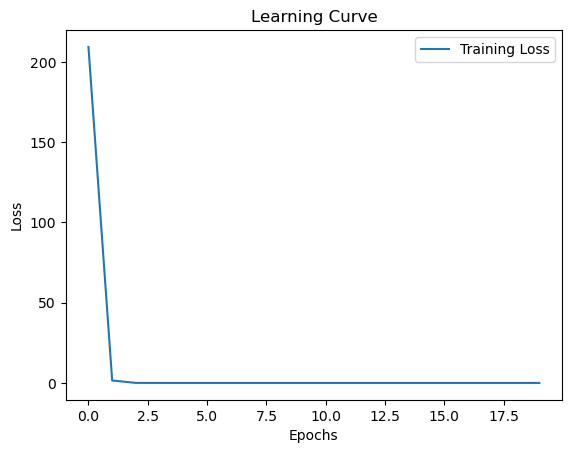

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


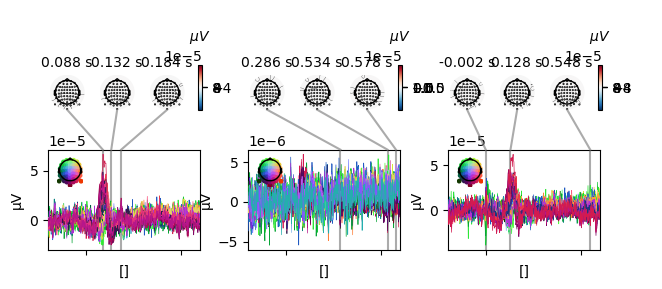

In [2]:

# GPU FIT WITH DATALOADER
#========
rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)


# PyTorch Ridge Model
# torch_ridge = Ridge(alpha=1e-3, fit_intercept=True, batch_size=1000, device=device)
# torch_ridge.fit(X_design, y_data, epochs=30, lr=0.01)
torch_ridge = Ridge(input_dim=X_design.shape[1], output_dim= y_data.shape[1], alpha= 24 , fit_intercept=False, batch_size=200000, device=device)
torch_ridge.fit(X_design, y_data, epochs=20, lr=0.03, momentum=0)

# Plot learning curve
torch_ridge.plot_learning_curve()
coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
rERP_model.coef_ =  coeffs
# # Predictions should now have shape (13000, 3)
# torch_predictions = torch_ridge.predict(X_torch)
fig = rERP_model.plot_coefs()
plt.show()

In [ ]:
#sheduler version:
import pandas as pd
import mne
from pydeconv.utils import *
from pydeconv import *
from sklearn.model_selection import KFold, GridSearchCV
import torch
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Check for available device
device = ('cuda' if torch.cuda.is_available() else 'cpu')

class Ridge:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = []
        
        # Define the nn.Linear layer with the fit_intercept parameter controlling bias
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)

    def fit(self, X, y, epochs=1000, lr=0.01, momentum=0, scheduler_step_size=10, scheduler_gamma=0.1):
        n_samples = X.shape[0]
        
        optimizer = optim.SGD(self.linear.parameters(), lr=lr, momentum=momentum)
        
        # Scheduler to reduce learning rate at regular intervals
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step_size, gamma=scheduler_gamma)

        # Convert data to CPU tensors only (avoiding full GPU memory usage initially)
        X_tensor = torch.tensor(X.todense(), dtype=torch.float32)  # Keep on CPU
        y_tensor = torch.tensor(y, dtype=torch.float32)  # Keep on CPU
        dataset = TensorDataset(X_tensor, y_tensor)
        data_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        # Training loop
        for epoch in range(epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in data_loader:
                # Move mini-batch to GPU
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                
                # Forward pass
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                epoch_loss += loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Step the scheduler after each epoch
            scheduler.step()

            avg_loss = epoch_loss / len(data_loader)
            self.loss_history.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4e}, LR: {scheduler.get_last_lr()[0]:.6f}")

    def model(self, x):
        return self.linear(x)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.linear.weight ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

    def plot_learning_curve(self):
        plt.plot(self.loss_history, label="Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Learning Curve")
        plt.legend()
        plt.show()

# # Load parameter, data and features
# #==================================
# data_path = "./example_data/"
# settings = analyze_data()
# features = pd.read_csv(data_path + "629959_full_metadata.csv") 
# raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)

# # Initialize the model
# #=====================
# rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)
# X_design = rERP_model.create_matrix()
# y_data   = rERP_model.get_nonzero_data()


Analyzing data with model: targMin
Time range: -0.2 to 0.6
Solver: ridge
Reading /home/dac/Documents/Repos/PyDeconv/example_data/629959_analysis.fdt
Reading 0 ... 1389499  =      0.000 ...  2778.998 secs...


/tmp/ipykernel_52104/1042086450.py:90: RuntimeWarning: Unknown types found, setting as type EEG:
eye: ['L-AREA', 'L-GAZE-X', 'L-GAZE-Y', 'TIME']
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)
/tmp/ipykernel_52104/1042086450.py:90: RuntimeWarning: Not setting positions of 8 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)



Model Name: targMin
First Intercept Event Type: fixation
Second Intercept Event Type: saccade
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 64

Model Description:
Intercept: True
Additive Features: ['ontarget']
Interactions: None

creating default splines: 5 cubic B-splines matrix

Original Design Matrix Shape:
X_design shape: (1389500, 2807)
y_data shape: (1389500, 64)



In [ ]:
rERP_model.

<PyDeconv | tmin, tmax : (-0.200, 0.600), estimator : <class 'sklearn.linear_model._ridge.Ridge'>, features : [intercept, ..., 5], fit: True>

Analyzing data with model: targMin
Time range: -0.2 to 0.6
Solver: ridge
Reading /Users/dac/Documents/repos/PyDeconv/example_data/629959_analysis.fdt
Reading 0 ... 1389499  =      0.000 ...  2778.998 secs...


/var/folders/gf/gp61rxzn3pz1rqw464l71d7w0000gn/T/ipykernel_64728/859357621.py:211: RuntimeWarning: Unknown types found, setting as type EEG:
eye: ['L-AREA', 'L-GAZE-X', 'L-GAZE-Y', 'TIME']
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)
/var/folders/gf/gp61rxzn3pz1rqw464l71d7w0000gn/T/ipykernel_64728/859357621.py:211: RuntimeWarning: Not setting positions of 8 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)



Model Name: targMin
First Intercept Event Type: fixation
Second Intercept Event Type: saccade
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 64

Model Description:
Intercept: True
Additive Features: ['ontarget']
Interactions: None

creating default splines: 5 cubic B-splines matrix

Original Design Matrix Shape:
X_design shape: (1389500, 2807)
y_data shape: (1389500, 64)


Model Name: targMin
First Intercept Event Type: fixation
Second Intercept Event Type: saccade
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 64

Model Description:
Intercept: True
Additive Features: ['ontarget']
Interactions: None

Epoch 0/50, Loss: 0.149721, MSE: 0.149686, Ridge: 0.000036, Elapsed: 0:01:30, ETA: 1:14:15
Epoch 10/50, Loss: 0.000190, MSE: 0.000190, Ridge: 0.000000, Elapsed: 0:01:54, ETA: 0:06:47
Epoch 20/50, Loss: 0.000268, MSE: 0.000268, Ridge: 0.000000, Elapsed: 0:02:20, ETA: 0:03:13
Epoch 30/50, Loss: 0.001989, MSE: 0.001989, Ridge: 0.000000, Elaps

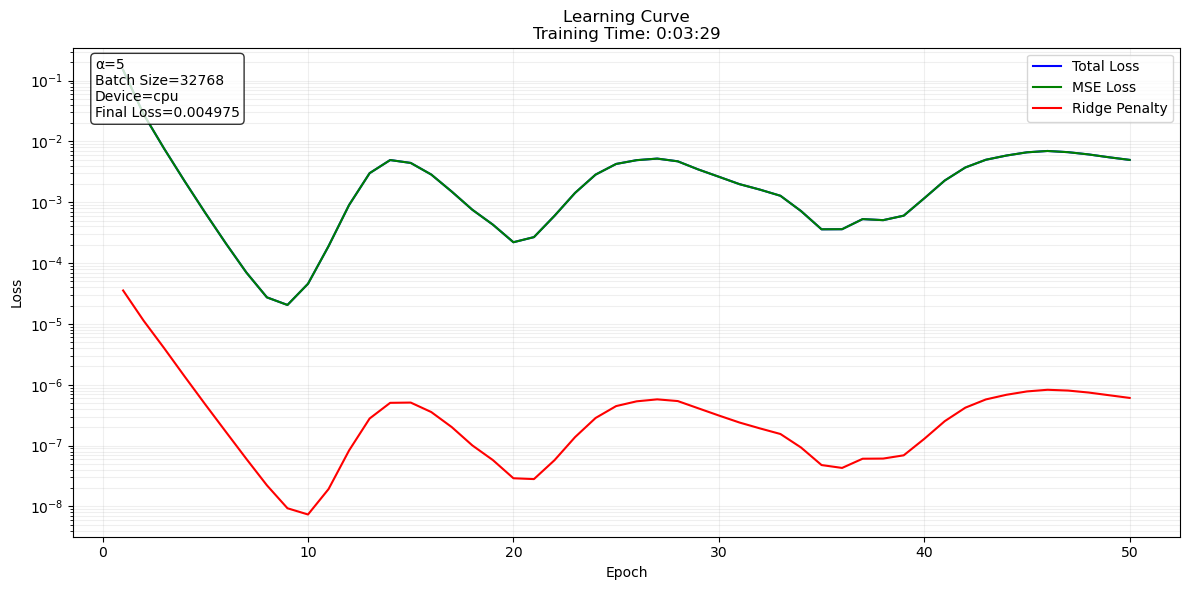

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


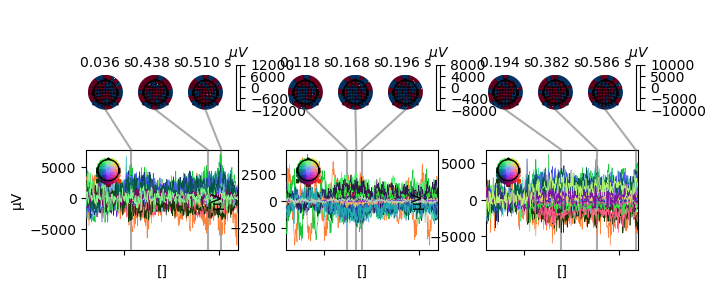

In [ ]:
#LAST TRY
import pandas as pd
import mne
from pydeconv.utils import *
from pydeconv import *
from sklearn.model_selection import KFold, GridSearchCV
import torch
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import time
from datetime import timedelta
# Check for available device
device = ('cuda' if torch.cuda.is_available() else 'cpu')

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = {'total': [], 'mse': [], 'ridge': []}
        self.training_time = None
        
        # Initialize weights closer to zero
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        if fit_intercept:
            nn.init.zeros_(self.linear.bias)
        
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def normalize_data(self, X, y):
        """Center the data like sklearn"""
        if self.X_mean is None:
            # Compute statistics on CPU to save GPU memory
            self.X_mean = X.mean(dim=0, keepdim=True)
            self.y_mean = y.mean(dim=0, keepdim=True) if self.fit_intercept else None
            self.X_std = torch.sqrt(torch.sum((X - self.X_mean)**2, dim=0, keepdim=True) / X.shape[0])
        
        # Normalize on CPU before moving to GPU
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        y_normalized = y - self.y_mean if self.fit_intercept else y
        
        return X_normalized, y_normalized

    def fit(self, X, y, epochs=1000, lr=0.01):
        start_time = time.time()
        
        # Convert inputs to torch tensors if needed
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X.todense(), dtype=torch.float32)
        if not isinstance(y, torch.Tensor):
            y = torch.tensor(y, dtype=torch.float32)
        
        # Keep original data on CPU and normalize there
        X, y = self.normalize_data(X, y)
        n_samples = X.shape[0]
        
        optimizer = optim.Adam(self.linear.parameters(), lr=lr, eps=1e-8)
        
        for epoch in range(epochs):
            running_loss = 0.0
            running_mse = 0.0
            running_ridge = 0.0
            
            # Process in batches
            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)
                
                # Move batch to device
                X_batch = X[i:batch_end].to(self.device)
                y_batch = y[i:batch_end].to(self.device)
                
                optimizer.zero_grad()
                predictions = self.linear(X_batch)
                
                # Calculate loss components
                batch_size = batch_end - i
                mse_loss = torch.sum((predictions - y_batch) ** 2) / (2 * n_samples)
                ridge_penalty = (self.alpha / (2 * n_samples)) * torch.sum(self.linear.weight ** 2)
                loss = mse_loss + ridge_penalty
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.linear.parameters(), max_norm=1.0)
                optimizer.step()
                
                # Accumulate losses (detach to prevent memory leak)
                running_loss += loss.detach().cpu().item() * batch_size
                running_mse += mse_loss.detach().cpu().item() * batch_size
                running_ridge += ridge_penalty.detach().cpu().item() * batch_size
                
                # Clear cache after each batch
                torch.cuda.empty_cache()
                
                # Move batch tensors back to CPU
                del X_batch
                del y_batch
            
            # Calculate average losses
            avg_loss = running_loss / n_samples
            avg_mse = running_mse / n_samples
            avg_ridge = running_ridge / n_samples
            
            # Store losses
            self.loss_history['total'].append(avg_loss)
            self.loss_history['mse'].append(avg_mse)
            self.loss_history['ridge'].append(avg_ridge)
            
            # Early stopping check
            if epoch > 10 and abs(self.loss_history['total'][-1] - self.loss_history['total'][-2]) < 1e-7:
                print(f"Converged at epoch {epoch}")
                break
                
            if epoch % 10 == 0:
                elapsed = time.time() - start_time
                eta = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
                print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.6f}, "
                      f"MSE: {avg_mse:.6f}, Ridge: {avg_ridge:.6f}, "
                      f"Elapsed: {timedelta(seconds=int(elapsed))}, "
                      f"ETA: {timedelta(seconds=int(eta))}")
        
        self.training_time = time.time() - start_time
        print(f"\nTraining completed in {timedelta(seconds=int(self.training_time))}")

    def predict(self, X):
        """Predict like sklearn's Ridge"""
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        
        # Normalize on CPU
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        
        # Process in batches to save memory
        predictions = []
        self.linear.eval()
        with torch.no_grad():
            for i in range(0, X.shape[0], self.batch_size):
                batch_end = min(i + self.batch_size, X.shape[0])
                X_batch = X_normalized[i:batch_end].to(self.device)
                
                batch_pred = self.linear(X_batch)
                if self.fit_intercept:
                    batch_pred = batch_pred + self.y_mean
                
                predictions.append(batch_pred.cpu())
                
                del X_batch
                torch.cuda.empty_cache()
        
        return torch.cat(predictions, dim=0).numpy()

    def get_coefficients(self):
        """Get coefficients in the original scale like sklearn"""
        with torch.no_grad():
            # Get weights on CPU
            weights = self.linear.weight.cpu()
            
            # Rescale weights
            scaled_weights = weights / (self.X_std + 1e-8).cpu()
            
            # Get intercept if fitted
            if self.fit_intercept:
                intercept = self.y_mean.cpu() - torch.mm(self.X_mean.cpu(), scaled_weights.t())
            else:
                intercept = torch.zeros(self.linear.out_features)
            
            return scaled_weights.numpy(), intercept.numpy()

    def plot_learning_curve(self, log_scale=True):
        """Plot the learning curve showing total loss, MSE, and ridge penalty components"""
        plt.figure(figsize=(12, 6))
        epochs = range(1, len(self.loss_history['total']) + 1)
        
        plt.plot(epochs, self.loss_history['total'], 'b-', label='Total Loss')
        plt.plot(epochs, self.loss_history['mse'], 'g-', label='MSE Loss')
        plt.plot(epochs, self.loss_history['ridge'], 'r-', label='Ridge Penalty')
        
        plt.title(f'Learning Curve\nTraining Time: {timedelta(seconds=int(self.training_time))}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        
        if log_scale:
            plt.yscale('log')
        
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        
        details = (f'α={self.alpha}\n'
                  f'Batch Size={self.batch_size}\n'
                  f'Device={self.device}\n'
                  f'Final Loss={self.loss_history["total"][-1]:.6f}')
        plt.text(0.02, 0.98, details, 
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()

# Load parameter, data and features
#==================================
data_path = "./example_data/"
settings = analyze_data()
features = pd.read_csv(data_path + "629959_full_metadata.csv") 
raw     = mne.io.read_raw_eeglab(data_path + "629959_analysis.set", preload=True)

# Initialize the model
#=====================
rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)
X_design = rERP_model.create_matrix()
y_data   = rERP_model.get_nonzero_data()


        
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    rERP_model = PyDeconv(settings = settings , features = features, eeg = raw)
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim= y_data.shape[1], alpha= 5 , fit_intercept=False, batch_size=32768, device=device)
    torch_ridge.fit(X_design, y_data, epochs=20, lr=0.05)
    # Plot learning curve
    torch_ridge.plot_learning_curve()
    coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    rERP_model.coef_ =  coeffs
    fig = rERP_model.plot_coefs()
    plt.show()

Epoch 0/10, Total Loss: 4.905082, MSE: 4.904525, Ridge: 0.000557, Elapsed: 0:01:48, ETA: 0:16:18

Training completed in 0:02:35.042290


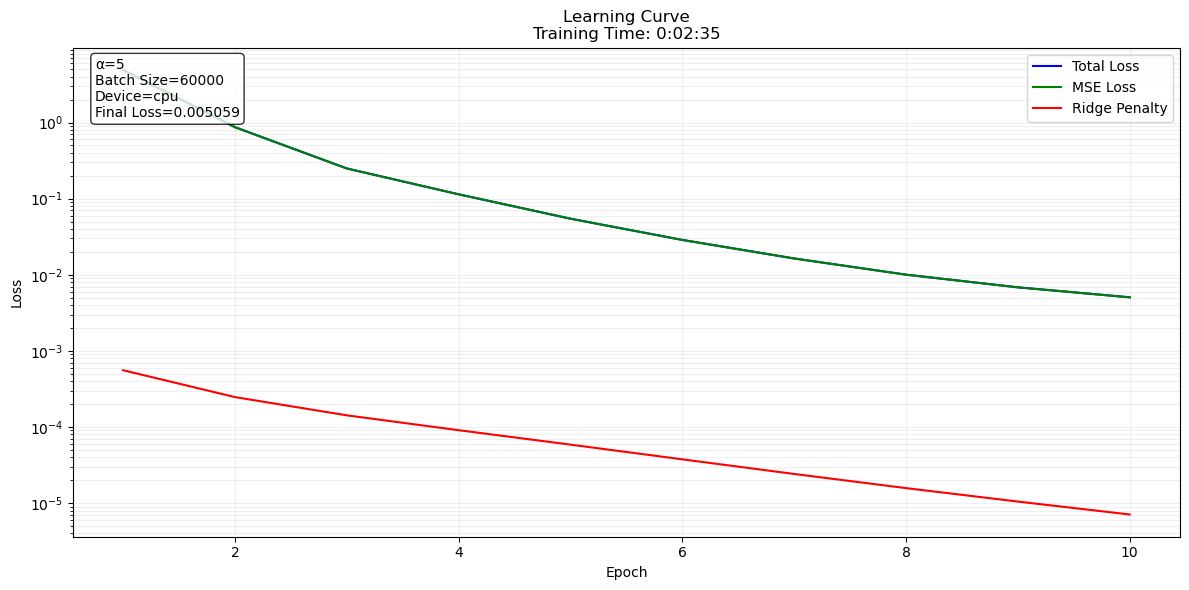

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


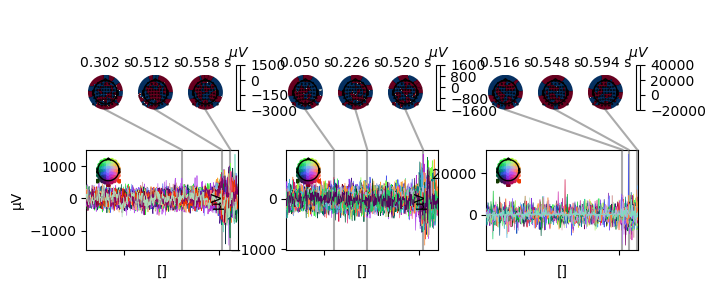

In [2]:
torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim= y_data.shape[1], alpha= 5 , fit_intercept=False, batch_size=60000, device=device)
torch_ridge.fit(X_design, y_data, epochs=10, lr=0.001)
# Plot learning curve
torch_ridge.plot_learning_curve()
coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
rERP_model.coef_ =  coeffs
fig = rERP_model.plot_coefs()
plt.show()

Epoch 0/20, Total Loss: 1.407694, MSE: 1.407683, Ridge: 0.000011, Elapsed: 0:01:14, ETA: 0:23:44
Epoch 10/20, Total Loss: 0.013363, MSE: 0.013363, Ridge: 0.000000, Elapsed: 0:01:33, ETA: 0:01:16

Training completed in 0:01:56.950588


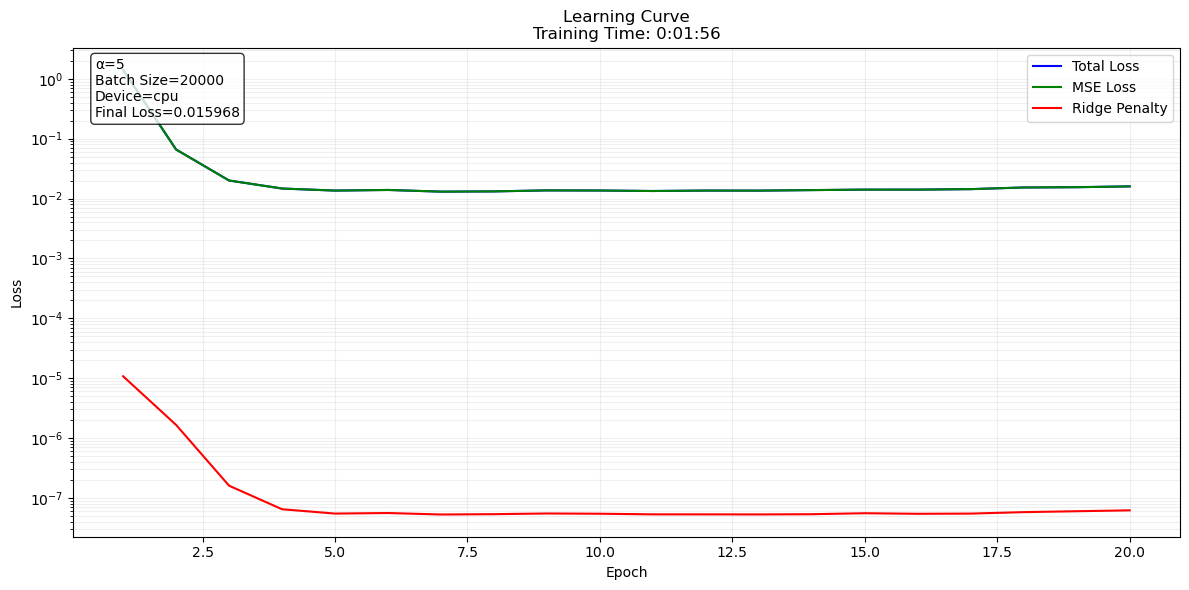

Predictions shape: (480045, 1)


ValueError: Info (64) and data (1) must have same number of channels.

<Figure size 1000x500 with 0 Axes>

In [7]:
#try same code from v1 with one channel:

import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import timedelta

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = {'total': [], 'mse': [], 'ridge': []}
        self.training_time = None
        
        # Initialize weights closer to zero
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        if fit_intercept:
            nn.init.zeros_(self.linear.bias)
        
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def normalize_data(self, X, y):
        """Center the data like sklearn"""
        if self.X_mean is None:
            self.X_mean = X.mean(dim=0, keepdim=True)
            self.y_mean = y.mean(dim=0, keepdim=True)
            
            # Only scale X like sklearn's Ridge
            self.X_std = torch.sqrt(torch.sum((X - self.X_mean)**2, dim=0, keepdim=True) / X.shape[0])
            self.y_std = None  # Don't scale y
        
        # Center and scale X, only center y
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        y_normalized = y - self.y_mean if self.fit_intercept else y
        
        return X_normalized, y_normalized

    def loss(self, predictions, y):
        """
        Implement loss exactly like sklearn's Ridge:
        Loss = (1/(2*n_samples)) * ||y - Xw||^2 + (alpha/(2*n_samples)) * ||w||^2
        """
        n_samples = y.shape[0]
        
        # MSE term
        mse_loss = torch.sum((predictions - y) ** 2) / (2 * n_samples)
        
        # L2 regularization term (exclude bias from regularization like sklearn)
        ridge_penalty = (self.alpha / (2 * n_samples)) * torch.sum(self.linear.weight ** 2)
        
        return mse_loss + ridge_penalty, mse_loss.item(), ridge_penalty.item()

    def fit(self, X, y, epochs=1000, lr=0.01):
        start_time = time.time()
        
        # Convert inputs to torch tensors if needed
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if not isinstance(y, torch.Tensor):
            y = torch.tensor(y, dtype=torch.float32)
        
        # Move to device
        X = X.to(self.device)
        y = y.to(self.device)
        
        # Normalize data
        X, y = self.normalize_data(X, y)
        n_samples = X.shape[0]
        
        # Use Adam with very small epsilon like sklearn's default solver
        optimizer = optim.Adam(self.linear.parameters(), lr=lr, eps=1e-8)
        
        for epoch in range(epochs):
            total_loss = 0
            total_mse = 0
            total_ridge = 0
            num_batches = 0
            
            # Process in batches
            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)
                X_batch = X[i:batch_end]
                y_batch = y[i:batch_end]
                
                optimizer.zero_grad()
                predictions = self.linear(X_batch)
                loss, mse, ridge = self.loss(predictions, y_batch)
                loss.backward()
                
                # Gradient clipping for stability
                torch.nn.utils.clip_grad_norm_(self.linear.parameters(), max_norm=1.0)
                
                optimizer.step()
                total_loss += loss.item() * (batch_end - i)
                total_mse += mse * (batch_end - i)
                total_ridge += ridge * (batch_end - i)
                num_batches += 1
            
            # Calculate average losses
            avg_loss = total_loss / n_samples
            avg_mse = total_mse / n_samples
            avg_ridge = total_ridge / n_samples
            
            # Store losses
            self.loss_history['total'].append(avg_loss)
            self.loss_history['mse'].append(avg_mse)
            self.loss_history['ridge'].append(avg_ridge)
            
            # Early stopping if loss is stable
            if epoch > 10 and abs(self.loss_history['total'][-1] - self.loss_history['total'][-2]) < 1e-7:
                print(f"Converged at epoch {epoch}")
                break
            
            if epoch % 10 == 0:
                elapsed = time.time() - start_time
                eta = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
                print(f"Epoch {epoch}/{epochs}, Total Loss: {avg_loss:.6f}, "
                      f"MSE: {avg_mse:.6f}, Ridge: {avg_ridge:.6f}, "
                      f"Elapsed: {timedelta(seconds=int(elapsed))}, "
                      f"ETA: {timedelta(seconds=int(eta))}")
        
        self.training_time = time.time() - start_time
        print(f"\nTraining completed in {timedelta(seconds=self.training_time)}")

    def predict(self, X):
        """Predict like sklearn's Ridge"""
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        
        X = X.to(self.device)
        
        self.linear.eval()
        with torch.no_grad():
            X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
            predictions = self.linear(X_normalized)
            if self.fit_intercept:
                predictions = predictions + self.y_mean
            
        return predictions.cpu().numpy()

    def get_coefficients(self):
        """Get coefficients in the original scale like sklearn"""
        with torch.no_grad():
            # Get weights
            weights = self.linear.weight.cpu()
            
            # Rescale weights
            scaled_weights = weights / (self.X_std + 1e-8).cpu()
            
            # Get intercept if fitted
            if self.fit_intercept:
                intercept = self.y_mean.cpu() - torch.mm(self.X_mean.cpu(), scaled_weights.t())
            else:
                intercept = torch.zeros(self.linear.out_features)
            
            return scaled_weights.numpy(), intercept.numpy()

    def plot_learning_curve(self, log_scale=True):
        """
        Plot the learning curve showing total loss, MSE, and ridge penalty components
        """
        plt.figure(figsize=(12, 6))
        epochs = range(1, len(self.loss_history['total']) + 1)
        
        plt.plot(epochs, self.loss_history['total'], 'b-', label='Total Loss')
        plt.plot(epochs, self.loss_history['mse'], 'g-', label='MSE Loss')
        plt.plot(epochs, self.loss_history['ridge'], 'r-', label='Ridge Penalty')
        
        plt.title(f'Learning Curve\nTraining Time: {timedelta(seconds=int(self.training_time))}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        
        if log_scale:
            plt.yscale('log')
        
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        
        # Add training details as text
        details = (f'α={self.alpha}\n'
                  f'Batch Size={self.batch_size}\n'
                  f'Device={self.device}\n'
                  f'Final Loss={self.loss_history["total"][-1]:.6f}')
        plt.text(0.02, 0.98, details, 
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate or load your design matrix for deconvolution (X_design)
    # and your response vector/matrix (y_data), ensuring that X_design 
    # properly reflects event separation with a Toeplitz structure if needed.
    X_torch = torch.tensor(X_design.toarray()).float().to(device)  # Convert to dense PyTorch tensor
    y_torch = torch.tensor(y_data).float().to(device)

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=False, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=20, lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)
    coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


Epoch 0/10, Total Loss: 56.639879, MSE: 56.515378, Ridge: 0.124501, Elapsed: 0:01:11, ETA: 0:10:45

Training completed in 0:01:40.580065


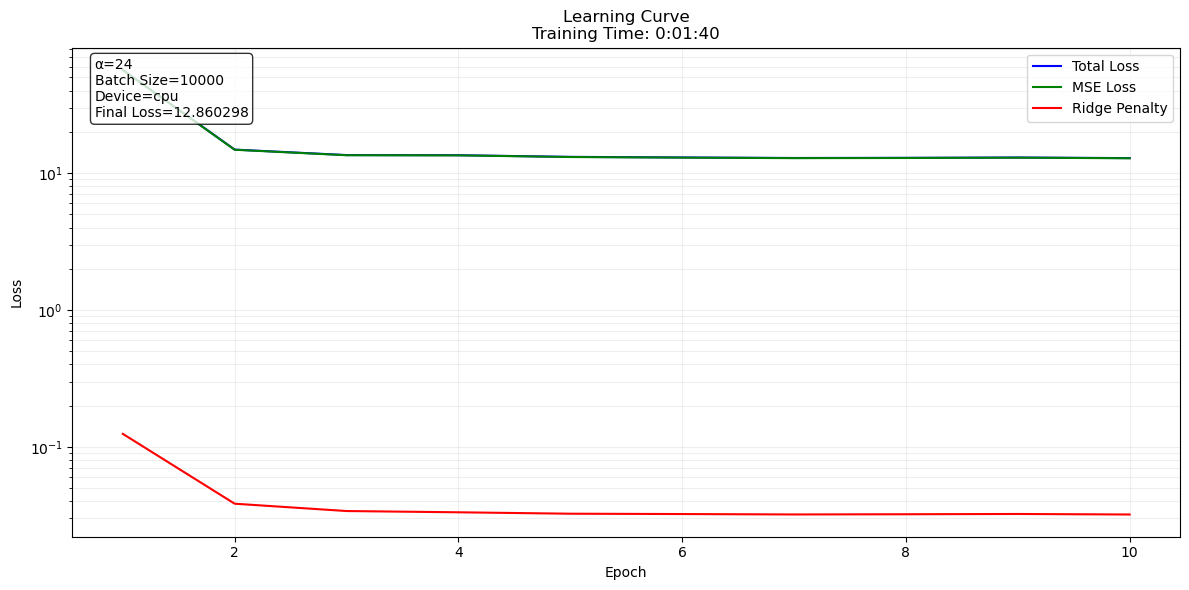

In [32]:
# Instantiate and train the deconvolution Ridge model
torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim= y_data.shape[1], alpha=24, fit_intercept=False, batch_size=10000, device=device)
torch_ridge.fit(X_torch, y_torch, epochs=10, lr=0.05)
# Plot learning curve
torch_ridge.plot_learning_curve()

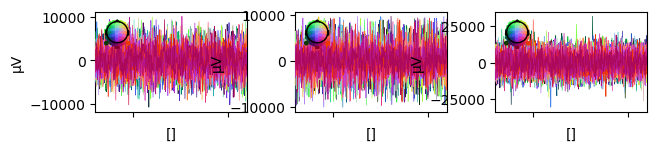

In [27]:
coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
rERP_model.coef_ =  coeffs
rERP_model.plot_coefs(top_topos=False)

NameError: name 'Info' is not defined

In [20]:
coeffs.shape

(1, 2807)